# 🌍 Geographical Analysis

This notebook implements the ninth dimension of our analytical framework: **Geographical Analysis**.

**Objective:** Mapping market share across regions and identifying hotspot cities for potential expansion.

## 1. Setup and Data Loading

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('ggplot')

# Load data
df = pd.read_csv('../Amazon.csv')
success_orders = df[df['OrderStatus'].isin(['Delivered', 'Shipped'])].copy()

## 2. Revenue by State
Identifying 'Power States' that drive the most volume.

C:\Users\shame\AppData\Local\Temp\ipykernel_16044\805729558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_performance.index, y=state_performance.values, palette='viridis')


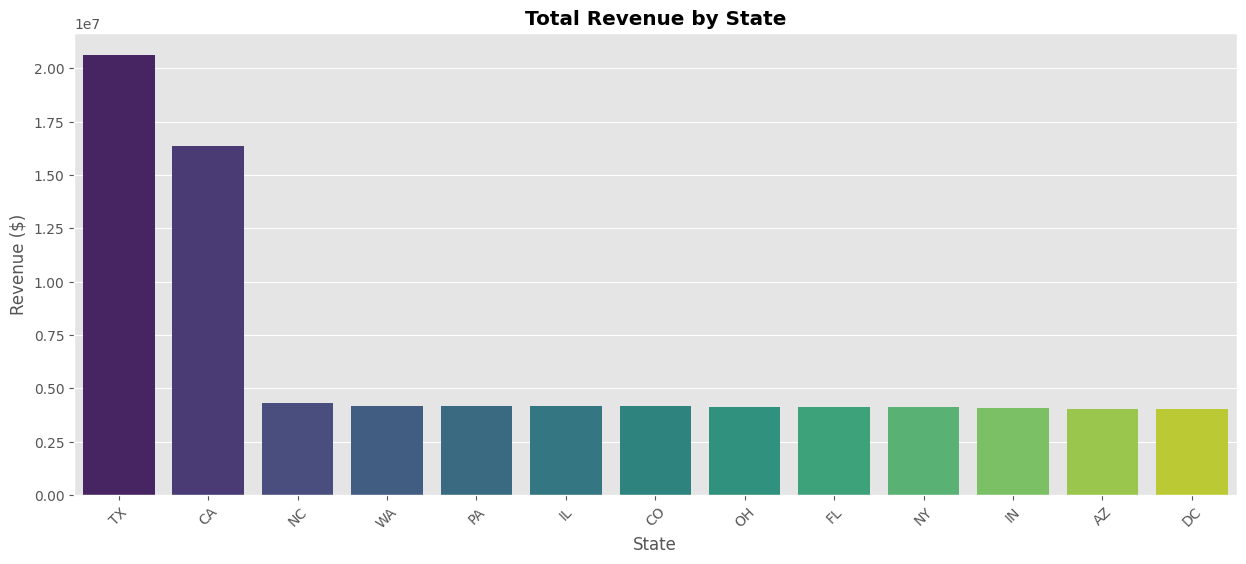

In [6]:
state_performance = success_orders.groupby('State')['TotalAmount'].sum().sort_values(ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x=state_performance.index, y=state_performance.values, palette='viridis')
plt.title('Total Revenue by State', fontweight='bold')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.show()

## 3. Hotspot Cities
Analyzing the top 15 cities by order volume.

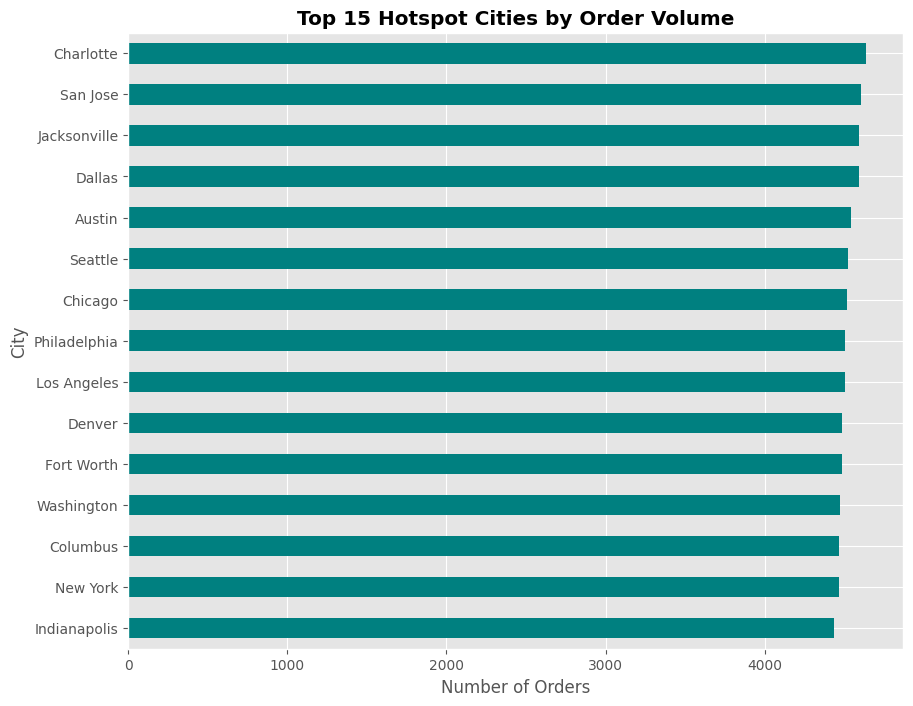

In [7]:
city_orders = success_orders['City'].value_counts().head(15)

plt.figure(figsize=(10, 8))
city_orders.plot(kind='barh', color='teal')
plt.title('Top 15 Hotspot Cities by Order Volume', fontweight='bold')
plt.xlabel('Number of Orders')
plt.gca().invert_yaxis()
plt.show()

## 4. Market Concentration
How much of our revenue is concentrated in the top 5 states?

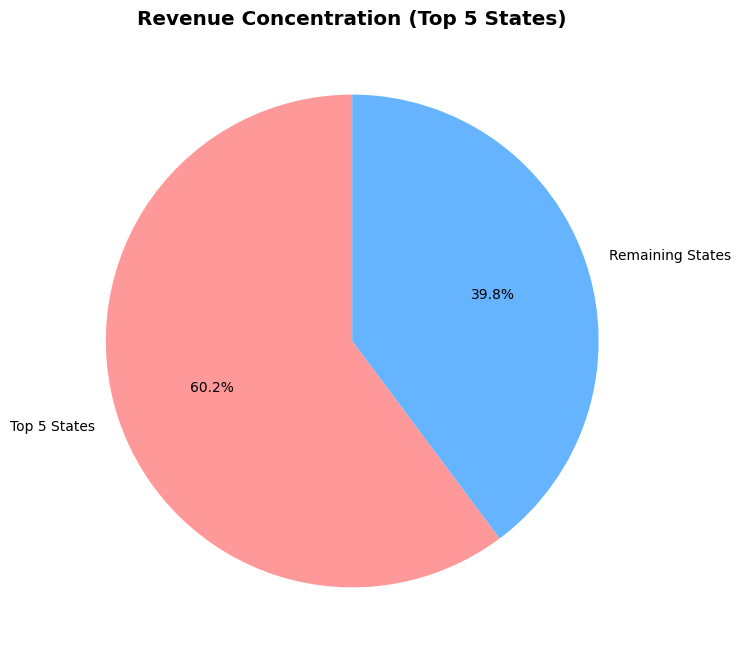

In [8]:
top_5 = state_performance.head(5).sum()
others = state_performance.tail(-5).sum()
concentration = pd.Series([top_5, others], index=['Top 5 States', 'Remaining States'])

plt.figure(figsize=(8, 8))
concentration.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Revenue Concentration (Top 5 States)', fontweight='bold')
plt.ylabel('')
plt.show()